In [1]:
# TITULO: Ingenieria de Datos - Placas (JSON a YOLO + Estratificacion)
# OBJETIVO: Estandarizar etiquetas, limpiar duplicados y generar splits estratificados.

import os
import glob
import shutil
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import yaml
import imagehash
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

# --- RUTAS ---
# Origen (Staging - Datos crudos)
SOURCE_PATH = '../../data/processed/02_placas_original'

# Destino A: Tu Propuesta (Estratificado y Balanceado)
DEST_PATH_CLEAN = '../../datasets/02_placas'

# Destino B: Linea Base (Distribucion Original de Kaggle)
DEST_PATH_BASELINE = '../../datasets/02_placas_baseline'

# Semilla para reproducibilidad
RANDOM_SEED = 42

print("Entorno configurado.")

Entorno configurado.


In [ ]:
def inventory_dataset(root_path):
    data_pairs = []
    
    # 1. Busqueda Recursiva de Imagenes
    extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG']
    all_images = []
    for ext in extensions:
        all_images.extend(glob.glob(os.path.join(root_path, '**', ext), recursive=True))
    
    print(f"Escaneando {len(all_images)} imagenes...")
    
    for img_path in tqdm(all_images):
        dirname = os.path.dirname(img_path)
        basename = os.path.splitext(os.path.basename(img_path))[0]
        full_path_str = os.path.abspath(img_path)
        
        # 2. Buscar JSON (mismo nombre base)
        json_path = os.path.join(dirname, basename + '.json')
        
        # Fallback: Buscar en carpetas hermanas si no esta junto
        if not os.path.exists(json_path):
            json_path = os.path.join(dirname.replace('images', 'json'), basename + '.json')
            
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    data = json.load(f)
                
                if not data: continue

                # 3. Detectar Split Original (Para la comparativa)
                path_parts = full_path_str.lower().replace('\\', '/').split('/')
                original_split = 'train' # Default si no encuentra nada
                if 'test' in path_parts: original_split = 'test'
                elif 'val' in path_parts or 'valid' in path_parts: original_split = 'val'
                
                # Agregamos a la lista
                data_pairs.append({
                    'id': basename,
                    'image_path': full_path_str,
                    'json_content': data,  # Guardamos contenido en memoria
                    'original_split': original_split
                })
                
            except Exception as e:
                print(f"Error leyendo JSON {json_path}: {e}")
    
    return pd.DataFrame(data_pairs)

# Ejecutar Inventario
df_placas = inventory_dataset(SOURCE_PATH)
print(f"Inventario completado: {len(df_placas)} pares validos.")

Escaneando 1975 imagenes...


  0%|          | 0/1975 [00:00<?, ?it/s]

Inventario completado: 1975 pares validos.


/tmp/ipykernel_12283/49921098.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='original_split', data=df_placas, palette='viridis', order=['train', 'val', 'test'])


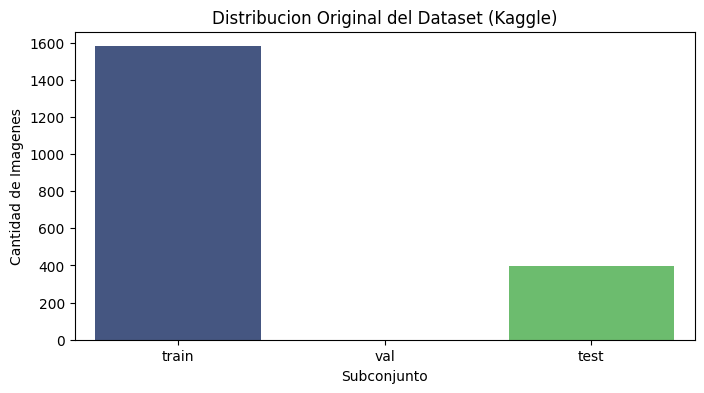

In [3]:
# Graficar como venian los datos originalmente
plt.figure(figsize=(8, 4))
sns.countplot(x='original_split', data=df_placas, palette='viridis', order=['train', 'val', 'test'])
plt.title('Distribucion Original del Dataset (Kaggle)')
plt.xlabel('Subconjunto')
plt.ylabel('Cantidad de Imagenes')
plt.show()

# Nota: Si falta 'val' o 'test', es un argumento fuerte para tu tesis sobre por que re-hiciste el split.

In [4]:
def analyze_and_remove_duplicates(df, hash_size=16):
    print("Buscando duplicados visuales (PHash)...")
    
    hashes = {}          
    drop_indices = []    
    duplicate_log = []   
    
    for idx, row in tqdm(df.iterrows(), total=df.shape[0]):
        try:
            with Image.open(row['image_path']) as img:
                h = str(imagehash.phash(img, hash_size=hash_size))
                
                if h in hashes:
                    # Duplicado encontrado
                    drop_indices.append(idx)
                    
                    original_id = df.loc[hashes[h], 'id']
                    duplicate_log.append({
                        'Hash': h,
                        'Conservada': original_id,
                        'Eliminada': row['id']
                    })
                else:
                    hashes[h] = idx
        except:
            drop_indices.append(idx)
            
    # Guardar reporte CSV
    if duplicate_log:
        report_path = '../../data/processed/02_placas_duplicados.csv'
        pd.DataFrame(duplicate_log).to_csv(report_path, index=False)
        print(f"Reporte de duplicados guardado en: {report_path}")
        print(f"Se eliminaran {len(duplicate_log)} imagenes redundantes.")

    return df.drop(drop_indices).reset_index(drop=True)

df_clean = analyze_and_remove_duplicates(df_placas)
print(f"Dataset Limpio: {len(df_clean)} imagenes.")

Buscando duplicados visuales (PHash)...


  0%|          | 0/1975 [00:00<?, ?it/s]

Dataset Limpio: 1975 imagenes.


Calculando tamano de placas para estratificacion...


  0%|          | 0/1975 [00:00<?, ?it/s]

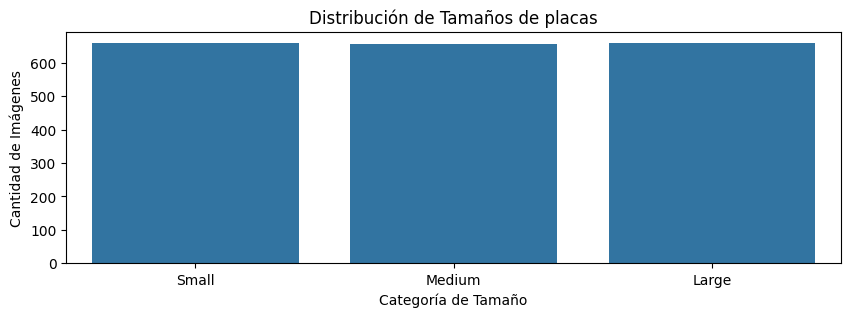

In [9]:
def add_stratification_metadata(df):
    print("Calculando tamano de placas para estratificacion...")
    areas = []
    
    for _, row in tqdm(df.iterrows(), total=len(df)):
        data = row['json_content']
        
        # Obtener dimensiones
        img_w = data.get('imageWidth')
        img_h = data.get('imageHeight')
        
        # Fallback si faltan dimensiones
        if not img_w or not img_h:
            img = cv2.imread(row['image_path'])
            if img is not None:
                img_h, img_w = img.shape[:2]
            else:
                areas.append(0)
                continue

        # Calcular area de la placa
        # Nota: Este dataset a veces tiene 'shapes' (labelme) o 'lps' (otros)
        # Vamos a buscar puntos genericamente
        max_area = 0
        
        # Logica hibrida para detectar formato
        shapes = data.get('shapes', [])
        if not shapes and 'lps' in data: shapes = data['lps'] # Soporte legacy
        
        for shape in shapes:
            # Buscar puntos
            points = shape.get('points')
            if not points and 'poly_coord' in shape: points = shape['poly_coord']
            
            if points:
                xs = [p[0] for p in points]
                ys = [p[1] for p in points]
                w = max(xs) - min(xs)
                h = max(ys) - min(ys)
                
                # Area normalizada (relativa a la imagen)
                norm_area = (w * h) / (img_w * img_h)
                if norm_area > max_area: max_area = norm_area
        
        areas.append(max_area)

    df['bbox_area'] = areas
    
    # Crear categorias (Small, Medium, Large)
    # Usamos qcut para dividir en 3 grupos de igual cantidad
    try:
        df['size_group'] = pd.qcut(df['bbox_area'], q=3, labels=['Small', 'Medium', 'Large'])
    except:
        df['size_group'] = 'Unknown' # Si hay muy pocos datos
        
    return df

df_clean = add_stratification_metadata(df_clean)

# Ver distribucion de tamanos
plt.figure(figsize=(10,3))
sns.countplot(x='size_group', data=df_clean)
plt.title('Distribución de Tamaños de placas')
plt.xlabel('Categoría de Tamaño')
plt.ylabel('Cantidad de Imágenes')
plt.show()

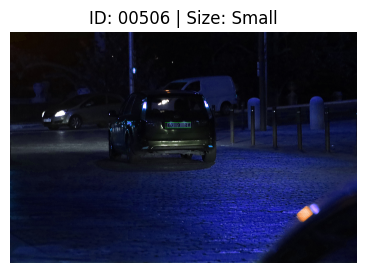

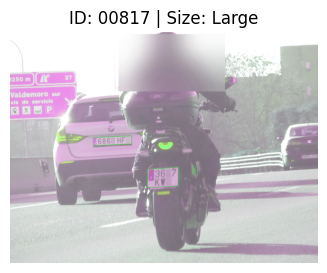

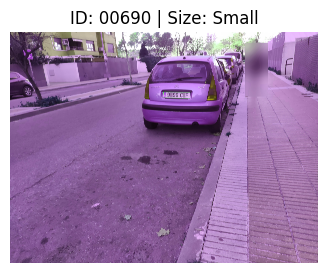

In [11]:
def visualize_samples(df, num=3):
    samples = df.sample(num)
    for _, row in samples.iterrows():
        img = cv2.imread(row['image_path'])
        data = row['json_content']
        
        # Dibujar (logica simplificada para visualizacion)
        shapes = data.get('shapes', [])
        if not shapes and 'lps' in data: shapes = data['lps']
        
        for s in shapes:
            pts = s.get('points')
            if not pts and 'poly_coord' in s: pts = s['poly_coord']
            if pts:
                pts = np.array(pts, np.int32)
                cv2.polylines(img, [pts], True, (0, 255, 0), 3)
        
        plt.figure(figsize=(5,3))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"ID: {row['id']} | Size: {row['size_group']}")
        plt.axis('off')
        plt.show()

visualize_samples(df_clean)

In [12]:
def process_and_export(df, destination, strategy='stratified'):
    if os.path.exists(destination): shutil.rmtree(destination)
    
    # Definir Splits
    if strategy == 'stratified':
        # Tu propuesta: Balanceado por tamano
        train, temp = train_test_split(df, test_size=0.2, stratify=df['size_group'], random_state=RANDOM_SEED)
        val, test = train_test_split(temp, test_size=0.5, stratify=temp['size_group'], random_state=RANDOM_SEED)
        split_map = {'train': train, 'val': val, 'test': test}
        print(f" Generando Dataset PROPUESTO (Estratificado) en: {destination}")
        
    else:
        # Baseline: Usar lo que venia en el zip
        train = df[df['original_split'] == 'train']
        val = df[df['original_split'] == 'val']
        test = df[df['original_split'] == 'test']
        # Si no habia val original, usamos parte del test o train (ajuste basico)
        if val.empty and not test.empty: val, test = train_test_split(test, test_size=0.5, random_state=RANDOM_SEED)
        split_map = {'train': train, 'val': val, 'test': test}
        print(f" Generando Dataset BASELINE (Original) en: {destination}")

    # Procesamiento
    for split_name, split_df in split_map.items():
        img_dir = os.path.join(destination, split_name, 'images')
        lbl_dir = os.path.join(destination, split_name, 'labels')
        os.makedirs(img_dir, exist_ok=True)
        os.makedirs(lbl_dir, exist_ok=True)
        
        for _, row in tqdm(split_df.iterrows(), desc=f"{split_name}", total=len(split_df)):
            # 1. Copiar Imagen
            shutil.copy(row['image_path'], os.path.join(img_dir, f"{row['id']}.jpg"))
            
            # 2. Convertir JSON -> YOLO .txt
            data = row['json_content']
            img_w = data.get('imageWidth')
            img_h = data.get('imageHeight')
            
            # Fallback dimensiones
            if not img_w or not img_h:
                im_pil = Image.open(row['image_path'])
                img_w, img_h = im_pil.size
            
            yolo_lines = []
            
            # Extraer poligonos
            shapes = data.get('shapes', [])
            if not shapes and 'lps' in data: shapes = data['lps']
            
            for shape in shapes:
                pts = shape.get('points')
                if not pts and 'poly_coord' in shape: pts = shape['poly_coord']
                
                if pts:
                    # Min/Max para caja
                    xs = [p[0] for p in pts]
                    ys = [p[1] for p in pts]
                    
                    x_min, x_max = min(xs), max(xs)
                    y_min, y_max = min(ys), max(ys)
                    
                    # Centro y Tamano
                    bw = x_max - x_min
                    bh = y_max - y_min
                    bx = x_min + (bw / 2)
                    by = y_min + (bh / 2)
                    
                    # Normalizar
                    bnx = bx / img_w
                    bny = by / img_h
                    bnw = bw / img_w
                    bnh = bh / img_h
                    
                    # Class 0
                    yolo_lines.append(f"0 {bnx:.6f} {bny:.6f} {bnw:.6f} {bnh:.6f}")
            
            # Guardar txt
            with open(os.path.join(lbl_dir, f"{row['id']}.txt"), 'w') as f:
                f.write('\n'.join(yolo_lines))

# Generar ambos datasets
process_and_export(df_clean, DEST_PATH_CLEAN, strategy='stratified')
process_and_export(df_clean, DEST_PATH_BASELINE, strategy='baseline')

 Generando Dataset PROPUESTO (Estratificado) en: ../../datasets/02_placas


train:   0%|          | 0/1580 [00:00<?, ?it/s]

val:   0%|          | 0/197 [00:00<?, ?it/s]

test:   0%|          | 0/198 [00:00<?, ?it/s]

 Generando Dataset BASELINE (Original) en: ../../datasets/02_placas_baseline


train:   0%|          | 0/1580 [00:00<?, ?it/s]

val:   0%|          | 0/197 [00:00<?, ?it/s]

test:   0%|          | 0/198 [00:00<?, ?it/s]

In [13]:
def create_yaml(path):
    content = {
        'path': os.path.abspath(path),
        'train': 'train/images',
        'val': 'val/images',
        'test': 'test/images',
        'names': {0: 'license_plate'}
    }
    with open(os.path.join(path, 'data.yaml'), 'w') as f:
        yaml.dump(content, f)

create_yaml(DEST_PATH_CLEAN)
create_yaml(DEST_PATH_BASELINE)
print("Archivos de configuracion YAML listos.")

Archivos de configuracion YAML listos.
